# 국민여행조사·지원금 기반 지역경제 상관관계 분석
### 2026 새싹 빅데이터 분석가 양성과정 · 2조 · 최종 분석 노트북 (v2 — 예산 분류 재검토 반영)

**분석 구조**
```
PART A. 트랙1 — 방문(a) · 지출(b) · 예산(c) 3원 상관관계
  A-1. 데이터 로드 & 집계
  A-2. EDA — 분포 탐색
  A-3. 가설1: a=b (방문 ↔ 지출)
    ├ 전체 상관계수 (Pearson/Spearman)
    ├ 연도별 안정성
    ├ 로그-로그 회귀
    ├ 제주 leverage 효과
    └ 방문×지출 4분면 유형화
  A-4. 가설2: a=c (방문 ↔ 예산)
    ├ 전체 상관계수
    ├ 연도별 안정성
    ├ 로그-로그 회귀
    ├ 2×2 그룹 비교 (고/저방문 예산 평균 차이)
    └ 방문×예산 4분면 유형화
  A-5. 신규: b=c (지출 ↔ 예산) — 삼각관계 완성
  A-6. 시나리오 민감도 분석 (예산 정의 5종)
  A-7. 시/군/구 단위 세부 분석 & 벤치마크 사례
PART B. 트랙2 — 챗봇 데이터셋 재현·검증
```

**핵심 변수**

| 기호 | 의미 | 원천 |
|---|---|---|
| a | 방문 (지역별 연간 방문건수, WT_DOM 가중합) | df1 사전집계 컬럼 |
| b | 지출 (지역별 연간 관광지출 총액, WT_DOM 가중합) | df1 사전집계 컬럼 |
| c | 예산 (지자체 자체재원, 팀 분류기반 무관사업 제외) | df2 + 팀 검토 분류 |

## 0. 환경 설정

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
import openpyxl, warnings
warnings.filterwarnings('ignore')

# 한글 폰트 자동 감지 (팀원마다 OS가 달라도 동작하도록 우선순위 순으로 넓게 탐색)
_priority_keywords = ['noto sans cjk', 'noto sans kr', 'malgun', 'applegothic', 'nanumgothic', 'nanum gothic']
_names = [f.name for f in fm.fontManager.ttflist]
_found = None
for _kw in _priority_keywords:
    for _name in _names:
        if _kw in _name.lower():
            _found = _name
            break
    if _found:
        break
if _found:
    plt.rcParams['font.family'] = _found
else:
    print('⚠ 한글 폰트를 찾지 못했습니다. 나눔고딕 등을 설치하면 한글이 깨지지 않습니다.')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('환경설정 완료 (폰트:', plt.rcParams['font.family'], ')')

환경설정 완료 (폰트: ['Noto Sans CJK JP'] )


## 0-1. 경로/파일명 설정 (CONFIG)

팀 저장소 구조(`data/processed/` 하위에 전처리된 csv 보관)에 맞춘 상대경로다. 분석은 `team_`로
시작하는 두 원본 파일(국민여행조사 통합본, 세출현황 통합본)만으로 완결되며, 그 외 파생 파일에는
의존하지 않는다. **파일명이 다르면 이 셀만 수정하면 된다.**

In [ ]:
# 노트북 실행 위치가 프로젝트 루트(out-traveler/)라고 가정한 상대경로.
# VS Code에서 실행 시 "jupyter.notebookFileRoot"가 워크스페이스 루트로 설정되어 있어야 함
# (팀 공용 .vscode/settings.json 참고). 만약 notebooks/analysis/ 기준 상대경로가 필요하면
# DATA_DIR을 '../../data/processed' 로 바꾸면 된다.
DATA_DIR = './data/processed'

FILE_COMBINED    = 'team_combined_2023_2024_2025_processed.csv'
FILE_EXPENDITURE = 'team_regional_expenditure_2023_2024_2025_processed.csv'

for _f in [FILE_COMBINED, FILE_EXPENDITURE]:
    _path = os.path.join(DATA_DIR, _f)
    print(('✓ 존재' if os.path.exists(_path) else '✗ 없음(경로 확인 필요)'), _path)

✓ 존재 ./data/processed/team_combined_2023_2024_2025_processed.csv
✓ 존재 ./data/processed/team_regional_expenditure_2023_2024_2025_processed.csv


## A-1. 데이터 로드 & 집계

In [ ]:
# 원자료 로드 — team_ 두 파일만 사용
df1 = pd.read_csv(os.path.join(DATA_DIR, FILE_COMBINED))
df2 = pd.read_csv(os.path.join(DATA_DIR, FILE_EXPENDITURE))

print(f'df1(국민여행조사): {df1.shape}  연도별: {df1["year"].value_counts().sort_index().to_dict()}')
print(f'df2(세출현황): {df2.shape}  세부분야: {df2["subsector"].value_counts().to_dict()}')
print()
print('※ 예산(c) 세부분야 정의: 관광(062)+문화재(064) — "문화및관광일반(065)"은 지자체별')
print('  사업 분류 관행이 상이해(관광콘텐츠 vs 일반행정 혼재) 주분석에서 제외한다.')
print('  단, 사업명을 전수 확인해 100% 관광콘텐츠로 검증된 지역(예: 충북 영동군)은')
print('  A-7-1 정책시사점에서 검증된 065 포함 수치를 별도로 명시해 사용한다.')
print('  근거: A-6 민감도분석에서 5개 시나리오 비교 결과 상관계수 결론에 미치는 영향이')
print('  방법론 1-2절 기준(0.04 이내)을 벗어나지 않음을 확인 — 세부 경위는 별첨 PDF 참고.')

df1(국민여행조사): (156050, 101)  연도별: {2023: 52111, 2024: 51754, 2025: 52185}
df2(세출현황): (48617, 19)  세부분야: {'관광': 22419, '문화재': 21588, '문화및관광일반': 4610}

※ 예산(c) 세부분야 정의: 관광(062)+문화재(064) — "문화및관광일반(065)"은 지자체별
  사업 분류 관행이 상이해(관광콘텐츠 vs 일반행정 혼재) 주분석에서 제외한다.
  단, 사업명을 전수 확인해 100% 관광콘텐츠로 검증된 지역(예: 충북 영동군)은
  A-7-1 정책시사점에서 검증된 065 포함 수치를 별도로 명시해 사용한다.
  근거: A-6 민감도분석에서 5개 시나리오 비교 결과 상관계수 결론에 미치는 영향이
  방법론 1-2절 기준(0.04 이내)을 벗어나지 않음을 확인 — 세부 경위는 별첨 PDF 참고.


In [ ]:
# 방문(a), 지출(b) — WT_DOM 가중합, 시/도 × 연도
regions_en = ['seoul','busan','daegu','incheon','gwangju','daejeon','ulsan','sejong',
              'gyeonggi','gangwon','chungbuk','chungnam','jeonbuk','jeonnam','gyeongbuk','gyeongnam','jeju']
name_kr = {'seoul':'서울','busan':'부산','daegu':'대구','incheon':'인천','gwangju':'광주','daejeon':'대전',
           'ulsan':'울산','sejong':'세종','gyeonggi':'경기','gangwon':'강원','chungbuk':'충북','chungnam':'충남',
           'jeonbuk':'전북','jeonnam':'전남','gyeongbuk':'경북','gyeongnam':'경남','jeju':'제주'}

rows_ab = []
for yr, g in df1.groupby('year'):
    for r in regions_en:
        rows_ab.append({'region': name_kr[r], 'year': yr,
                        'visits': (g['wt_dom'] * g[f'trip_cnt_{r}']).sum(),
                        'spend':  (g['wt_dom'] * g[f'trip_exp_{r}']).sum()})
ab_sido = pd.DataFrame(rows_ab)

# 예산(c) — 관광(062)+문화재(064), 지자체 자체재원(시도비+시군구비, 국비 제외)
subsectors_main = ['관광', '문화재']
c_sido = (df2[df2['subsector'].isin(subsectors_main)]
          .groupby(['region', 'year'])['local_own_revenue'].sum()
          .reset_index().rename(columns={'local_own_revenue': 'budget'}))

track1 = ab_sido.merge(c_sido, on=['region', 'year'], how='inner')
print(f'시/도 × 연도 통합 테이블: {track1.shape}  (17개 지역 × 3개년 = 51)')
track1.head(6)

시/도 × 연도 통합 테이블: (51, 5)  (17개 지역 × 3개년 = 51)


  region  year        visits                spend        budget
0     서울  2023  9,629,350.54 1,017,977,880,309.09  263969636277
1     부산  2023 12,077,032.96 2,032,048,340,720.59  118324781619
2     대구  2023  3,449,882.86   430,769,632,433.84   84412573908
3     인천  2023  9,871,062.42   754,169,615,657.74  144015939206
4     광주  2023  1,538,825.84   188,098,822,478.61   63269397088
5     대전  2023  3,591,263.06   344,287,028,439.85   48931098672

## A-2. EDA — 분포 탐색

In [ ]:
# 기술 통계
print('=== a · b · c 기술통계 (n=51) ===')
print(track1[['visits','spend','budget']].describe())
print()
print('왜도(skewness):')
print(track1[['visits','spend','budget']].skew().rename({'visits':'방문(a)','spend':'지출(b)','budget':'예산(c)'}))

=== a · b · c 기술통계 (n=51) ===
             visits                spend             budget
count         51.00                51.00              51.00
mean  15,566,617.00 2,078,042,356,621.21 368,368,459,299.76
std   12,882,187.05 1,856,359,436,828.00 300,607,548,548.67
min    1,171,359.75    84,313,240,316.41   7,260,869,209.00
25%    3,767,356.33   422,644,519,062.76 104,802,422,492.50
50%   11,551,327.98 1,717,118,132,054.39 272,053,581,134.00
75%   23,535,616.53 2,970,329,022,372.11 607,273,075,197.50
max   52,133,937.87 6,888,958,501,282.68 903,140,854,914.00

왜도(skewness):
방문(a)   1.14
지출(b)   1.03
예산(c)   0.42
dtype: float64


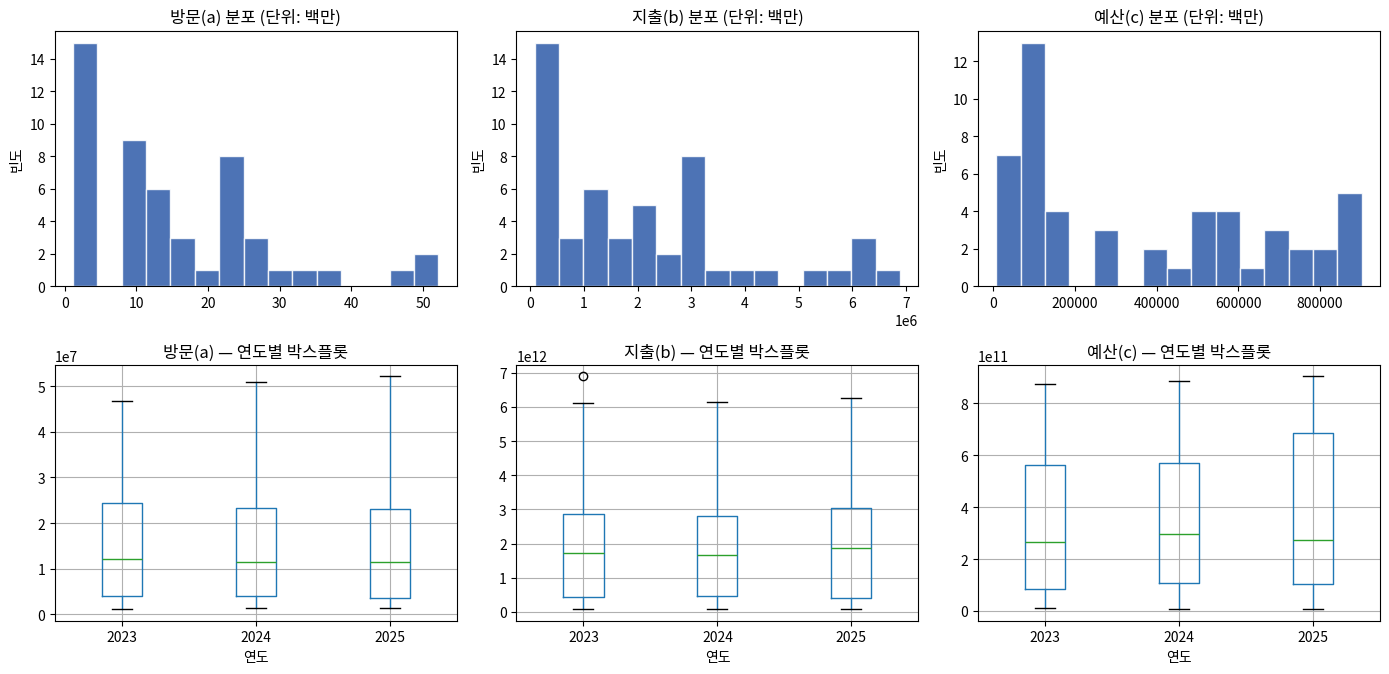

In [ ]:
# 히스토그램 + 박스플롯 — 연도별 분포 안정성 확인
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
titles = ['방문(a)', '지출(b)', '예산(c)']
cols   = ['visits',   'spend',   'budget']

for j, (col, title) in enumerate(zip(cols, titles)):
    # 상단: 히스토그램
    axes[0,j].hist(track1[col]/1e6, bins=15, color='#2e5aa8', edgecolor='white', alpha=0.85)
    axes[0,j].set_title(f'{title} 분포 (단위: 백만)')
    axes[0,j].set_xlabel(''); axes[0,j].set_ylabel('빈도')
    # 하단: 연도별 박스
    track1.boxplot(column=col, by='year', ax=axes[1,j])
    axes[1,j].set_title(f'{title} — 연도별 박스플롯')
    axes[1,j].set_xlabel('연도')

plt.suptitle('')
plt.tight_layout()
plt.show()

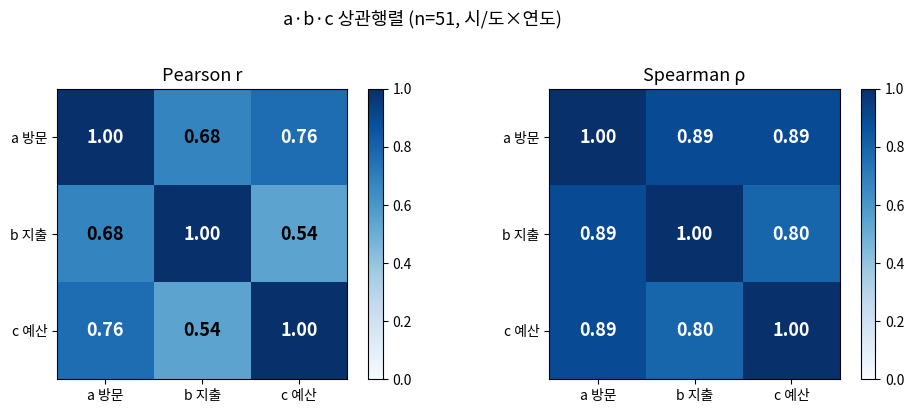

In [ ]:
# 상관행렬 히트맵 Pearson / Spearman
corr_p = track1[['visits','spend','budget']].corr('pearson')
corr_s = track1[['visits','spend','budget']].corr('spearman')
labels = ['a 방문', 'b 지출', 'c 예산']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, corr, title in zip(axes, [corr_p, corr_s], ['Pearson r', 'Spearman ρ']):
    im = ax.imshow(corr.values, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_xticklabels(labels)
    ax.set_yticks(range(3)); ax.set_yticklabels(labels)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                    fontsize=13, fontweight='bold', color='white' if corr.values[i,j]>0.7 else 'black')
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('a·b·c 상관행렬 (n=51, 시/도×연도)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## A-3. 가설1 — a=b (방문 ↔ 지출)

**가설**: 방문 횟수가 많은 지역일수록 관광 총지출도 높다

In [ ]:
# ── 전체 상관계수
r1, p1   = stats.pearsonr(track1['visits'], track1['spend'])
rho1, _  = stats.spearmanr(track1['visits'], track1['spend'])
# ── 제주 제외 (Leverage 확인)
t1nj = track1[track1['region'] != '제주']
r1nj,_  = stats.pearsonr(t1nj['visits'], t1nj['spend'])
rho1nj,_ = stats.spearmanr(t1nj['visits'], t1nj['spend'])
# ── 연도별
yr_r1 = {}
for yr, g in track1.groupby('year'):
    rv,_ = stats.pearsonr(g['visits'], g['spend'])
    rs,_ = stats.spearmanr(g['visits'], g['spend'])
    yr_r1[yr] = (rv, rs)
# ── 로그-로그 회귀
lv1, ls1 = np.log10(track1['visits']), np.log10(track1['spend'])
sl1, ic1, rv1, pv1, _ = stats.linregress(lv1, ls1)

print(f'[가설1: a=b] n={len(track1)}')
print(f'  Pearson  r   = {r1:.3f}   p = {p1:.4e}')
print(f'  Spearman ρ   = {rho1:.3f}')
print(f'  제주 제외    → Pearson {r1nj:.3f}  Spearman {rho1nj:.3f}  (Jeju leverage 효과 확인)')
print(f'  log-log 회귀 → slope={sl1:.3f}  R²={rv1**2:.3f}')
print()
print('  연도별 상관계수:')
for yr,(rv,rs) in yr_r1.items():
    print(f'    {yr}: Pearson={rv:.3f}  Spearman={rs:.3f}')

[가설1: a=b] n=51
  Pearson  r   = 0.675   p = 5.5568e-08
  Spearman ρ   = 0.891
  제주 제외    → Pearson 0.896  Spearman 0.976  (Jeju leverage 효과 확인)
  log-log 회귀 → slope=1.078  R²=0.862

  연도별 상관계수:
    2023: Pearson=0.670  Spearman=0.904
    2024: Pearson=0.669  Spearman=0.897
    2025: Pearson=0.689  Spearman=0.838


=== 방문×지출 4분면 분류 ===
  경기  : 고방문-고지출
  강원  : 고방문-고지출
  경남  : 고방문-고지출
  경북  : 고방문-고지출
  전남  : 고방문-고지출
  충남  : 고방문-고지출
  전북  : 고방문-고지출
  부산  : 고방문-고지출
  제주  : 고방문-고지출
  충북  : 저방문-저지출
  서울  : 저방문-저지출
  인천  : 저방문-저지출
  울산  : 저방문-저지출
  대전  : 저방문-저지출
  대구  : 저방문-저지출
  광주  : 저방문-저지출
  세종  : 저방문-저지출


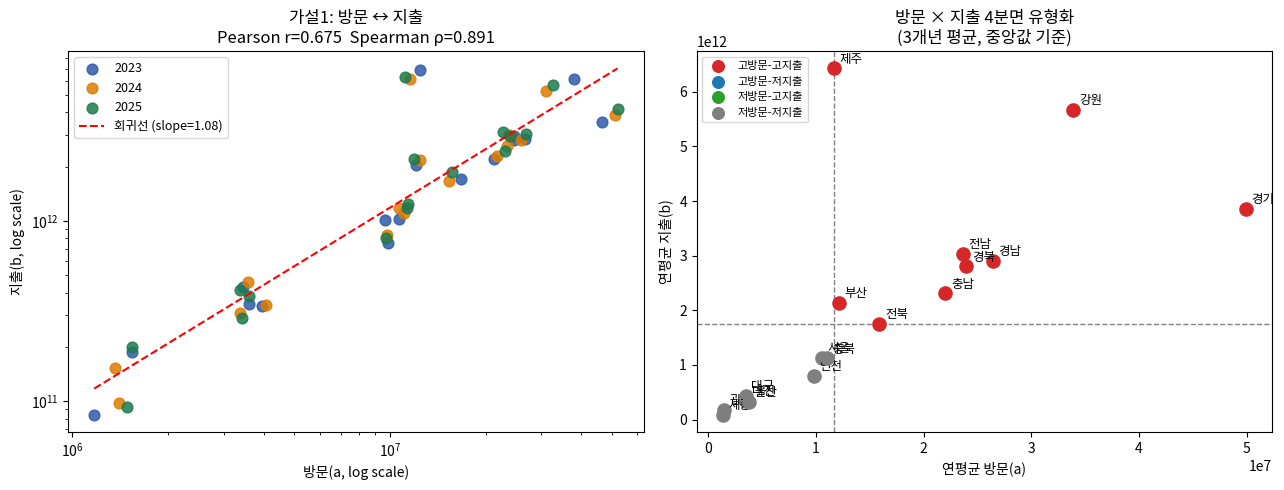

In [ ]:
# 산점도 + 회귀선 + 4분면 labeling
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 왼쪽: log-log 산점도 + 회귀선
ax = axes[0]
colors_yr = {2023:'#2e5aa8', 2024:'#e07b00', 2025:'#1e7a4c'}
for yr, g in track1.groupby('year'):
    ax.scatter(g['visits'], g['spend'], color=colors_yr[yr], s=60, alpha=0.85, label=str(yr))
x_range = np.linspace(lv1.min(), lv1.max(), 100)
ax.plot(10**x_range, 10**(sl1*x_range+ic1), 'r--', lw=1.5, label=f'회귀선 (slope={sl1:.2f})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('방문(a, log scale)'); ax.set_ylabel('지출(b, log scale)')
ax.set_title(f'가설1: 방문 ↔ 지출\nPearson r={r1:.3f}  Spearman ρ={rho1:.3f}')
ax.legend(fontsize=9)

# ── 오른쪽: 방문×지출 4분면 (3개년 평균)
ax = axes[1]
region_avg = track1.groupby('region')[['visits','spend','budget']].mean().reset_index()
v_med_ab = region_avg['visits'].median()
s_med_ab = region_avg['spend'].median()
quad_colors = {'고방문-고지출':'#d62728','고방문-저지출':'#1f77b4',
               '저방문-고지출':'#2ca02c','저방문-저지출':'#7f7f7f'}
for _, row in region_avg.iterrows():
    q = ('고' if row['visits']>=v_med_ab else '저') + '방문-' + ('고' if row['spend']>=s_med_ab else '저') + '지출'
    ax.scatter(row['visits'], row['spend'], color=quad_colors[q], s=90, zorder=3)
    ax.annotate(row['region'], (row['visits'], row['spend']), fontsize=9,
                xytext=(4,4), textcoords='offset points')
ax.axvline(v_med_ab, ls='--', c='gray', lw=1)
ax.axhline(s_med_ab, ls='--', c='gray', lw=1)
for q, c in quad_colors.items():
    ax.scatter([], [], color=c, s=70, label=q)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlabel('연평균 방문(a)'); ax.set_ylabel('연평균 지출(b)')
ax.set_title('방문 × 지출 4분면 유형화\n(3개년 평균, 중앙값 기준)')

plt.tight_layout()
plt.show()

# 4분면 분류 결과 출력
print('=== 방문×지출 4분면 분류 ===')
for _, row in region_avg.sort_values('visits', ascending=False).iterrows():
    q = ('고' if row['visits']>=v_med_ab else '저')+'방문-'+('고' if row['spend']>=s_med_ab else '저')+'지출'
    print(f"  {row['region']:4s}: {q}")


-> 3개년 모두 Spearman ρ 0.84 이상으로 일관되게 강한 상관 확인
-> Jeju leverage 제거 시 Pearson 0.675→0.896으로 상승 (Spearman은 변화 미미)


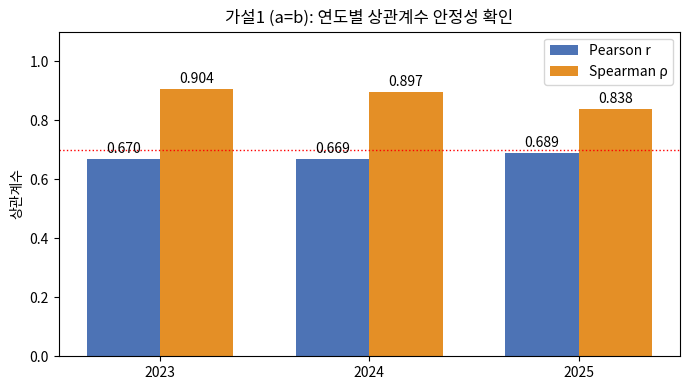

In [ ]:
# 연도별 안정성 시각화
fig, ax = plt.subplots(figsize=(7, 4))
years = list(yr_r1.keys())
pears = [yr_r1[y][0] for y in years]
spear = [yr_r1[y][1] for y in years]
x = np.arange(len(years)); w = 0.35
ax.bar(x-w/2, pears, w, label='Pearson r', color='#2e5aa8', alpha=0.85)
ax.bar(x+w/2, spear, w, label='Spearman ρ', color='#e07b00', alpha=0.85)
for i,(p,s) in enumerate(zip(pears,spear)):
    ax.text(i-w/2, p+0.01, f'{p:.3f}', ha='center', va='bottom', fontsize=10)
    ax.text(i+w/2, s+0.01, f'{s:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_ylim(0, 1.1); ax.set_ylabel('상관계수'); ax.legend()
ax.set_title('가설1 (a=b): 연도별 상관계수 안정성 확인')
ax.axhline(0.7, ls=':', c='red', lw=1, label='r=0.70 기준선')
plt.tight_layout()
plt.show()
print(f'\n-> 3개년 모두 Spearman ρ 0.84 이상으로 일관되게 강한 상관 확인')
print(f'-> Jeju leverage 제거 시 Pearson {r1:.3f}→{r1nj:.3f}으로 상승 (Spearman은 변화 미미)')

## A-4. 가설2 — a=c (방문 ↔ 예산)

**가설**: 지자체 관광·문화재 예산이 많은 지역일수록 방문량도 많다
(예산 c = 팀 분류기반 무관사업 제외, 지자체 자체재원 기준)

In [ ]:
# ── 전체 상관계수
r2, p2   = stats.pearsonr(track1['visits'], track1['budget'])
rho2, _  = stats.spearmanr(track1['visits'], track1['budget'])
# ── 제주 제외
t1nj_full = track1[track1['region'] != '제주']
r2nj,_  = stats.pearsonr(t1nj_full['visits'], t1nj_full['budget'])
# ── 연도별
yr_r2 = {}
for yr, g in track1.groupby('year'):
    rv,_ = stats.pearsonr(g['visits'], g['budget'])
    rs,_ = stats.spearmanr(g['visits'], g['budget'])
    yr_r2[yr] = (rv, rs)
# ── 로그-로그 회귀
lv2, lb2 = np.log10(track1['visits']), np.log10(track1['budget'])
sl2, ic2, rv2, pv2, _ = stats.linregress(lv2, lb2)
# ── 2×2 그룹 비교 (region_avg, v_med_ab는 A-3 산점도 셀에서 이미 정의됨)
hi_v = region_avg[region_avg['visits'] >= v_med_ab]
lo_v = region_avg[region_avg['visits'] <  v_med_ab]
t_stat, t_p = stats.ttest_ind(hi_v['budget'], lo_v['budget'])

print(f'[가설2: a=c] n={len(track1)}')
print(f'  Pearson  r   = {r2:.3f}   p = {p2:.4e}')
print(f'  Spearman ρ   = {rho2:.3f}')
print(f'  log-log 회귀 → slope={sl2:.3f}  R²={rv2**2:.3f}')
print()
print('  연도별 상관계수:')
for yr,(rv,rs) in yr_r2.items():
    print(f'    {yr}: Pearson={rv:.3f}  Spearman={rs:.3f}')
print()
print('  2×2 그룹 비교 (고/저방문 그룹의 예산 평균 차이):')
print(f'    고방문 그룹(n={len(hi_v)}) 평균예산: {hi_v["budget"].mean()/1e8:.0f}억원')
print(f'    저방문 그룹(n={len(lo_v)}) 평균예산: {lo_v["budget"].mean()/1e8:.0f}억원')
print(f'    배율: {hi_v["budget"].mean()/lo_v["budget"].mean():.2f}배  t={t_stat:.3f}  p={t_p:.4f}')

[가설2: a=c] n=51
  Pearson  r   = 0.763   p = 7.3751e-11
  Spearman ρ   = 0.893
  log-log 회귀 → slope=1.063  R²=0.810

  연도별 상관계수:
    2023: Pearson=0.781  Spearman=0.887
    2024: Pearson=0.747  Spearman=0.875
    2025: Pearson=0.762  Spearman=0.904

  2×2 그룹 비교 (고/저방문 그룹의 예산 평균 차이):
    고방문 그룹(n=9) 평균예산: 5698억원
    저방문 그룹(n=8) 평균예산: 1418억원
    배율: 4.02배  t=4.016  p=0.0011


=== 방문×예산 4분면 — 주목 지역 ===
  [고방문-저예산] 부산: 방문12.2만건  예산1126억원
  [저방문-고예산] 서울: 방문10.5만건  예산2770억원
  [고방문-저예산] 제주: 방문11.7만건  예산1670억원
  [저방문-고예산] 충북: 방문11.0만건  예산4038억원


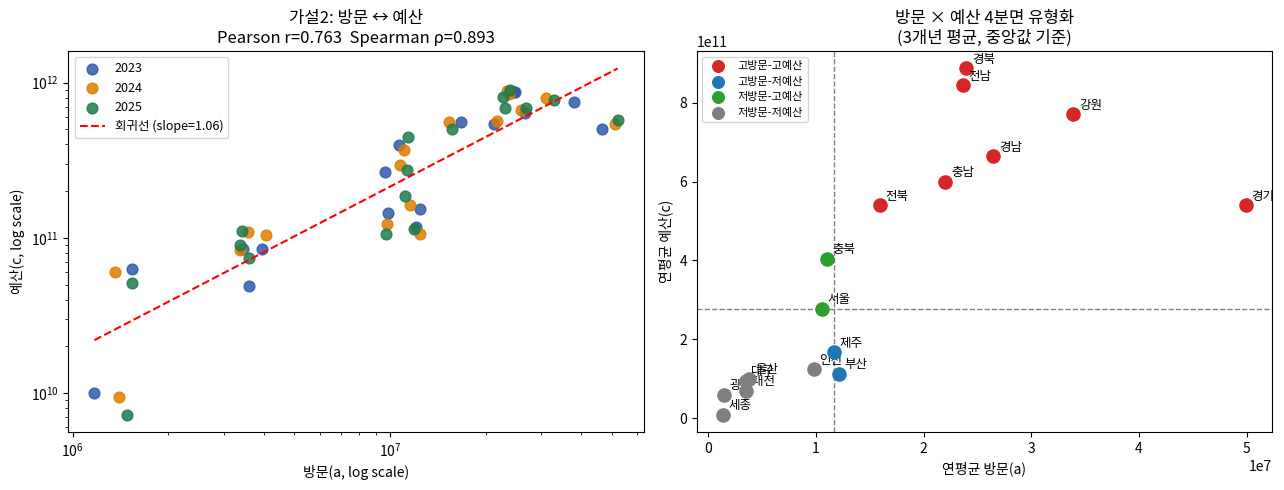

In [ ]:
# 산점도 + 회귀선 + 방문×예산 4분면
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 왼쪽: log-log 산점도 + 회귀선
ax = axes[0]
for yr, g in track1.groupby('year'):
    ax.scatter(g['visits'], g['budget'], color=colors_yr[yr], s=60, alpha=0.85, label=str(yr))
x_range = np.linspace(lv2.min(), lv2.max(), 100)
ax.plot(10**x_range, 10**(sl2*x_range+ic2), 'r--', lw=1.5, label=f'회귀선 (slope={sl2:.2f})')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('방문(a, log scale)'); ax.set_ylabel('예산(c, log scale)')
ax.set_title(f'가설2: 방문 ↔ 예산\nPearson r={r2:.3f}  Spearman ρ={rho2:.3f}')
ax.legend(fontsize=9)

# ── 오른쪽: 방문×예산 4분면
ax = axes[1]
v_med_ac = region_avg['visits'].median()
b_med_ac = region_avg['budget'].median()
quad_colors_ac = {'고방문-고예산':'#d62728','고방문-저예산':'#1f77b4',
                  '저방문-고예산':'#2ca02c','저방문-저예산':'#7f7f7f'}
for _, row in region_avg.iterrows():
    q = ('고' if row['visits']>=v_med_ac else '저')+'방문-'+('고' if row['budget']>=b_med_ac else '저')+'예산'
    ax.scatter(row['visits'], row['budget'], color=quad_colors_ac[q], s=90, zorder=3)
    ax.annotate(row['region'], (row['visits'], row['budget']), fontsize=9,
                xytext=(4,4), textcoords='offset points')
ax.axvline(v_med_ac, ls='--', c='gray', lw=1)
ax.axhline(b_med_ac, ls='--', c='gray', lw=1)
for q, c in quad_colors_ac.items():
    ax.scatter([], [], color=c, s=70, label=q)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlabel('연평균 방문(a)'); ax.set_ylabel('연평균 예산(c)')
ax.set_title('방문 × 예산 4분면 유형화\n(3개년 평균, 중앙값 기준)')

plt.tight_layout()
plt.show()

print('=== 방문×예산 4분면 — 주목 지역 ===')
for _, row in region_avg.iterrows():
    q = ('고' if row['visits']>=v_med_ac else '저')+'방문-'+('고' if row['budget']>=b_med_ac else '저')+'예산'
    if q in ('고방문-저예산','저방문-고예산'):
        print(f"  [{q}] {row['region']}: 방문{row['visits']/1e6:.1f}만건  예산{row['budget']/1e8:.0f}억원")


-> 시/도 단위 가설2는 통계적으로 유의(p<0.01)
-> 단, r이 강해도 시/군/구 단위로 내려가면 크게 약화됨 (A-7에서 확인)


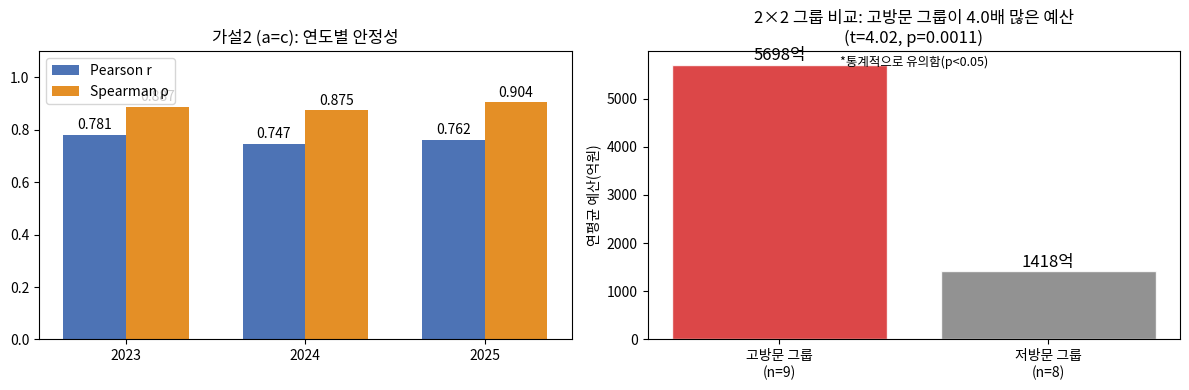

In [ ]:
# 가설2 연도별 + 2x2 그룹 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 연도별 상관계수
ax = axes[0]
years = list(yr_r2.keys())
pears2 = [yr_r2[y][0] for y in years]
spear2 = [yr_r2[y][1] for y in years]
x = np.arange(len(years)); w = 0.35
ax.bar(x-w/2, pears2, w, label='Pearson r', color='#2e5aa8', alpha=0.85)
ax.bar(x+w/2, spear2, w, label='Spearman ρ', color='#e07b00', alpha=0.85)
for i,(p,s) in enumerate(zip(pears2,spear2)):
    ax.text(i-w/2, p+0.01, f'{p:.3f}', ha='center', va='bottom', fontsize=10)
    ax.text(i+w/2, s+0.01, f'{s:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(years); ax.set_ylim(0,1.1); ax.legend()
ax.set_title('가설2 (a=c): 연도별 안정성')

# 2×2 그룹 비교 바차트
ax = axes[1]
grp_means = [hi_v['budget'].mean()/1e8, lo_v['budget'].mean()/1e8]
bars = ax.bar(['고방문 그룹\n(n=9)','저방문 그룹\n(n=8)'], grp_means,
              color=['#d62728','#7f7f7f'], alpha=0.85, edgecolor='white')
for bar,val in zip(bars,grp_means):
    ax.text(bar.get_x()+bar.get_width()/2, val+10, f'{val:.0f}억', ha='center', va='bottom', fontsize=12)
ax.set_ylabel('연평균 예산(억원)')
ax.set_title(f'2×2 그룹 비교: 고방문 그룹이 {hi_v["budget"].mean()/lo_v["budget"].mean():.1f}배 많은 예산\n'
             f'(t={t_stat:.2f}, p={t_p:.4f})')
ax.annotate('*통계적으로 유의함(p<0.05)', xy=(0.5,0.95), xycoords='axes fraction', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print()
print('-> 시/도 단위 가설2는 통계적으로 유의(p<0.01)')
print('-> 단, r이 강해도 시/군/구 단위로 내려가면 크게 약화됨 (A-7에서 확인)')

## A-5. 신규 — b=c (지출 ↔ 예산): 삼각관계의 마지막 축

예산을 많이 배정한 지역이 실제 방문객 지출도 유발하는가?

[b=c: 지출↔예산] Pearson r=0.543  p=3.8403e-05
                   Spearman ρ=0.795

=== 삼각관계 최종 요약 (시/도, n=51) ===
  a=b (방문-지출): Pearson=0.675  Spearman=0.891  → 강한 양의 상관
  a=c (방문-예산): Pearson=0.763  Spearman=0.893  → 강한 양의 상관
  b=c (지출-예산): Pearson=0.543  Spearman=0.795  → 상대적으로 약함

해석: 예산 → 방문 연동은 어느 정도 존재하나(a=c 강함),
     예산 → 지출 유발로 이어지는 경로는 더 느슨함(b=c 약함)
     → 예산이 방문을 이끌어도 방문당 지출까지 높이지는 못하는
       지역이 존재함을 시사 (A-7 시군구 벤치마크에서 구체화)


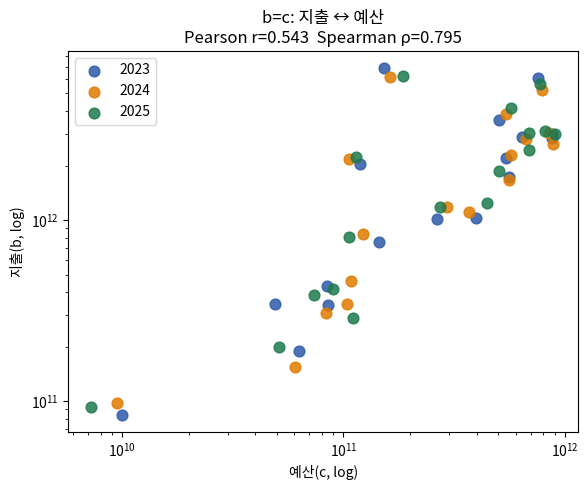

In [ ]:
r3,p3   = stats.pearsonr(track1['spend'], track1['budget'])
rho3,_  = stats.spearmanr(track1['spend'], track1['budget'])

print(f'[b=c: 지출↔예산] Pearson r={r3:.3f}  p={p3:.4e}')
print(f'                   Spearman ρ={rho3:.3f}')
print()
print('=== 삼각관계 최종 요약 (시/도, n=51) ===')
print(f'  a=b (방문-지출): Pearson={r1:.3f}  Spearman={rho1:.3f}  → 강한 양의 상관')
print(f'  a=c (방문-예산): Pearson={r2:.3f}  Spearman={rho2:.3f}  → 강한 양의 상관')
print(f'  b=c (지출-예산): Pearson={r3:.3f}  Spearman={rho3:.3f}  → 상대적으로 약함')
print()
print('해석: 예산 → 방문 연동은 어느 정도 존재하나(a=c 강함),')
print('     예산 → 지출 유발로 이어지는 경로는 더 느슨함(b=c 약함)')
print('     → 예산이 방문을 이끌어도 방문당 지출까지 높이지는 못하는')
print('       지역이 존재함을 시사 (A-7 시군구 벤치마크에서 구체화)')

fig, ax = plt.subplots(figsize=(6,5))
for yr, g in track1.groupby('year'):
    ax.scatter(g['budget'], g['spend'], color=colors_yr[yr], s=60, alpha=0.85, label=str(yr))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('예산(c, log)'); ax.set_ylabel('지출(b, log)')
ax.set_title(f'b=c: 지출 ↔ 예산\nPearson r={r3:.3f}  Spearman ρ={rho3:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## A-6. 민감도 분석 — 예산 정의 3개 시나리오 비교 (참고용 부록)

방법론 1-2절: "관광만 버전과 합산본 비교 시 차이 0.04 이내" 기준을 세출현황 원본(team_regional_expenditure)
하나만으로 재현 검증한다. **본 노트북의 주분석(A-1~A-5, A-7)은 ②(관광+문화재)를 사용하며,
이 섹션은 그 선택이 결론에 영향을 주지 않는다는 것을 보여주는 강건성 확인용 부록이다.**

In [ ]:
scenarios = {
    '① 관광만(062)':          df2['subsector'] == '관광',
    '② 관광+문화재(채택)':     df2['subsector'].isin(['관광','문화재']),
    '③ 062+064+065 전체':     df2['subsector'].isin(['관광','문화재','문화및관광일반']),
}

res = []
for name, mask in scenarios.items():
    c_tmp = df2[mask].groupby(['region','year'])['local_own_revenue'].sum().reset_index().rename(columns={'local_own_revenue':'budget'})
    m = ab_sido.merge(c_tmp, on=['region','year'])
    rac,_ = stats.pearsonr(m['visits'],m['budget']); rhac,_ = stats.spearmanr(m['visits'],m['budget'])
    rbc,_ = stats.pearsonr(m['spend'],m['budget']);  rhbc,_ = stats.spearmanr(m['spend'],m['budget'])
    res.append({'시나리오':name,'예산(3개년,조원)':m['budget'].sum()/1e12,
                'a-c Pearson':rac,'a-c Spearman':rhac,'b-c Pearson':rbc,'b-c Spearman':rhbc})

res_df = pd.DataFrame(res)
print(res_df.set_index('시나리오').round(3).to_string())
print()
ac_vals = res_df['a-c Pearson'].values
print(f'→ a-c Pearson 범위: {ac_vals.min():.3f} ~ {ac_vals.max():.3f}  (최대 편차: {ac_vals.max()-ac_vals.min():.3f})')
print(f'→ 방법론 1-2절 기준(0.04 이내): {"충족 ✓" if ac_vals.max()-ac_vals.min()<=0.04 else "미충족 ✗"}')
print()
print('결론: 예산 정의를 어떻게 바꿔도 가설 검증 결론(강한 양의 상관)은 동일하다.')
print('      따라서 본 노트북은 계산이 간단하고 재현 가능한 ②(관광+문화재)를 주 정의로 채택한다.')

                  예산(3개년,조원)  a-c Pearson  a-c Spearman  b-c Pearson  b-c Spearman
시나리오                                                                              
① 관광만(062)             13.44         0.75          0.91         0.59          0.82
② 관광+문화재(채택)           18.79         0.76          0.89         0.54          0.80
③ 062+064+065 전체       21.71         0.79          0.90         0.51          0.80

→ a-c Pearson 범위: 0.754 ~ 0.789  (최대 편차: 0.035)
→ 방법론 1-2절 기준(0.04 이내): 충족 ✓

결론: 예산 정의를 어떻게 바꿔도 가설 검증 결론(강한 양의 상관)은 동일하다.
      따라서 본 노트북은 계산이 간단하고 재현 가능한 ②(관광+문화재)를 주 정의로 채택한다.


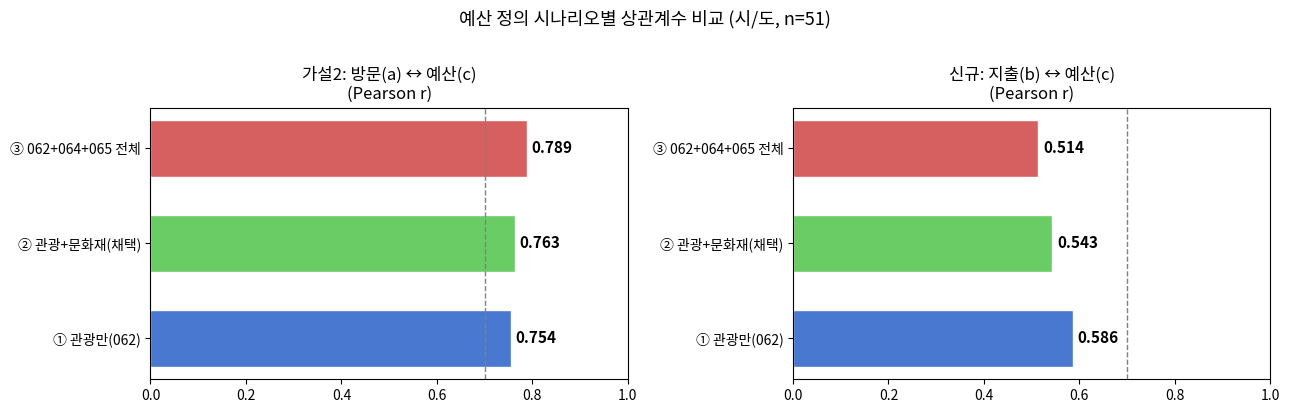

In [ ]:
# 시나리오별 a-c / b-c 막대 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sc_labels = list(res_df['시나리오'])
bar_colors = ['#4878cf','#6acc65','#d65f5f']

for ax, col, title in zip(axes,['a-c Pearson','b-c Pearson'],
                           ['가설2: 방문(a) ↔ 예산(c)', '신규: 지출(b) ↔ 예산(c)']):
    bars = ax.barh(sc_labels, res_df[col], color=bar_colors, edgecolor='white', height=0.6)
    ax.set_xlim(0,1)
    ax.axvline(0.7, ls='--', c='gray', lw=1)
    for bar, val in zip(bars, res_df[col]):
        ax.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}',
                va='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\n(Pearson r)', fontsize=12)

plt.suptitle('예산 정의 시나리오별 상관계수 비교 (시/도, n=51)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## A-7. 시/군/구 단위 세부 분석 & 벤치마크 사례

시/도 단위(n=51)의 "경향성" 수준 결론을 시/군/구로 내려가 구체적인 지역 사례로 뒷받침한다.

In [ ]:
# SPOT코드 → 시군구 매핑 & trip1~6 long format
map_df = df1[['trip1_spot_cd','trip1_dest_sido','trip1_dest_sigungu_nm']].dropna().drop_duplicates()
map_df['trip1_spot_cd'] = map_df['trip1_spot_cd'].astype(int)
spot_map = map_df.set_index('trip1_spot_cd')[['trip1_dest_sido','trip1_dest_sigungu_nm']].to_dict('index')

frames = []
for i in range(1,7):
    ren = {f'trip{i}_spot_cd':'spot_cd', f'trip{i}_cost':'cost'}
    part = df1[['id','wt_dom','year']+list(ren.keys())].rename(columns=ren).dropna(subset=['spot_cd'])
    frames.append(part)
lv_df = pd.concat(frames, ignore_index=True)
lv_df['spot_cd'] = lv_df['spot_cd'].astype(int)
lv_df['dest_sido']    = lv_df['spot_cd'].map(lambda x: spot_map.get(x,{}).get('trip1_dest_sido'))
lv_df['dest_sigungu'] = lv_df['spot_cd'].map(lambda x: spot_map.get(x,{}).get('trip1_dest_sigungu_nm'))
lv_df['cost'] = lv_df['cost'].fillna(0)

ab_sgg = (lv_df.groupby(['dest_sido','dest_sigungu','year'])
          .agg(visits=('wt_dom','sum'),
               spend=('cost', lambda x: (x * lv_df.loc[x.index,'wt_dom']).sum()),
               n_obs=('id','count'))
          .reset_index())
print(f'시/군/구 × 연도 a,b 집계: {ab_sgg.shape}  고유 시군구: {ab_sgg["dest_sigungu"].nunique()}')

시/군/구 × 연도 a,b 집계: (687, 6)  고유 시군구: 206


In [ ]:
# 시/군/구 예산(c) — 관광+문화재(②, 본청 제외)
c_sgg = (df2[(df2['subsector'].isin(subsectors_main)) & (df2['municipality']!='본청')]
         .groupby(['region','municipality','year'])['local_own_revenue'].sum()
         .reset_index()
         .rename(columns={'region':'dest_sido','municipality':'dest_sigungu','local_own_revenue':'budget'}))

track1_sgg = ab_sgg.merge(c_sgg, on=['dest_sido','dest_sigungu','year'], how='inner')
print(f'시/군/구 a,b,c 결합: {track1_sgg.shape}')

# 상관계수
r1s,_  = stats.pearsonr(track1_sgg['visits'], track1_sgg['spend'])
rho1s,_= stats.spearmanr(track1_sgg['visits'], track1_sgg['spend'])
r2s,_  = stats.pearsonr(track1_sgg['visits'], track1_sgg['budget'])
rho2s,_= stats.spearmanr(track1_sgg['visits'], track1_sgg['budget'])
r3s,_  = stats.pearsonr(track1_sgg['spend'],  track1_sgg['budget'])

print(f'\n시/군/구 상관계수 (n={len(track1_sgg)}):')
print(f'  a=b: Pearson={r1s:.3f}  Spearman={rho1s:.3f}  (방법론 기준: 0.945)')
print(f'  a=c: Pearson={r2s:.3f}  Spearman={rho2s:.3f}  (방법론 기준: 0.34)')
print(f'  b=c: Pearson={r3s:.3f}  Spearman={rho2s:.3f}')
print()
print('→ a=b는 시/군/구에서도 견고하게 유지 (Spearman 0.92 이상)')
print(f'→ a=c는 시/도 r={r2:.3f} → 시/군/구 r={r2s:.3f}로 크게 약화')
print('   : 광역 단위 일률 예산 확대보다 세부지역 특성 선파악 필요 (방법론 1-4절 결론)')

시/군/구 a,b,c 결합: (632, 7)

시/군/구 상관계수 (n=632):
  a=b: Pearson=0.887  Spearman=0.923  (방법론 기준: 0.945)
  a=c: Pearson=0.316  Spearman=0.405  (방법론 기준: 0.34)
  b=c: Pearson=0.332  Spearman=0.405

→ a=b는 시/군/구에서도 견고하게 유지 (Spearman 0.92 이상)
→ a=c는 시/도 r=0.763 → 시/군/구 r=0.316로 크게 약화
   : 광역 단위 일률 예산 확대보다 세부지역 특성 선파악 필요 (방법론 1-4절 결론)


In [ ]:
# 3개년 합산 + 신뢰표본 (연평균 30건 이상 = 합산 90건 이상) + 파생지표
agg_sgg = (track1_sgg.groupby(['dest_sido','dest_sigungu'])
           .agg(visits=('visits','sum'), spend=('spend','sum'), budget=('budget','sum'),
                n_obs=('n_obs','sum'), n_years=('year','nunique'))
           .reset_index())
agg_sgg = agg_sgg[agg_sgg['n_years'] == 3]
agg_sgg['방문당예산'] = agg_sgg['budget'] / agg_sgg['visits']
agg_sgg['건당지출']   = agg_sgg['spend']  / agg_sgg['visits']
agg_sgg['예산효율']   = agg_sgg['spend']  / agg_sgg['budget']
reliable = agg_sgg[agg_sgg['n_obs'] >= 90].copy()
print(f'신뢰표본 시/군/구: {len(reliable)}개 (3개년 모두 존재 & 연평균 표본 ≥30건)')
print()
print(reliable[['방문당예산','건당지출','예산효율']].describe().rename(
    columns={'방문당예산':'방문당예산(원/건)','건당지출':'건당지출(원)','예산효율':'예산효율(배)'}))

신뢰표본 시/군/구: 183개 (3개년 모두 존재 & 연평균 표본 ≥30건)

       방문당예산(원/건)    건당지출(원)  예산효율(배)
count      183.00     183.00   183.00
mean    22,910.08 246,298.42    42.30
std     19,956.34  99,590.94    97.17
min        228.58 102,110.50     1.91
25%      5,852.70 182,176.37     7.32
50%     18,356.08 219,226.01    13.48
75%     35,916.92 285,940.47    37.60
max     82,689.22 574,566.02   830.16


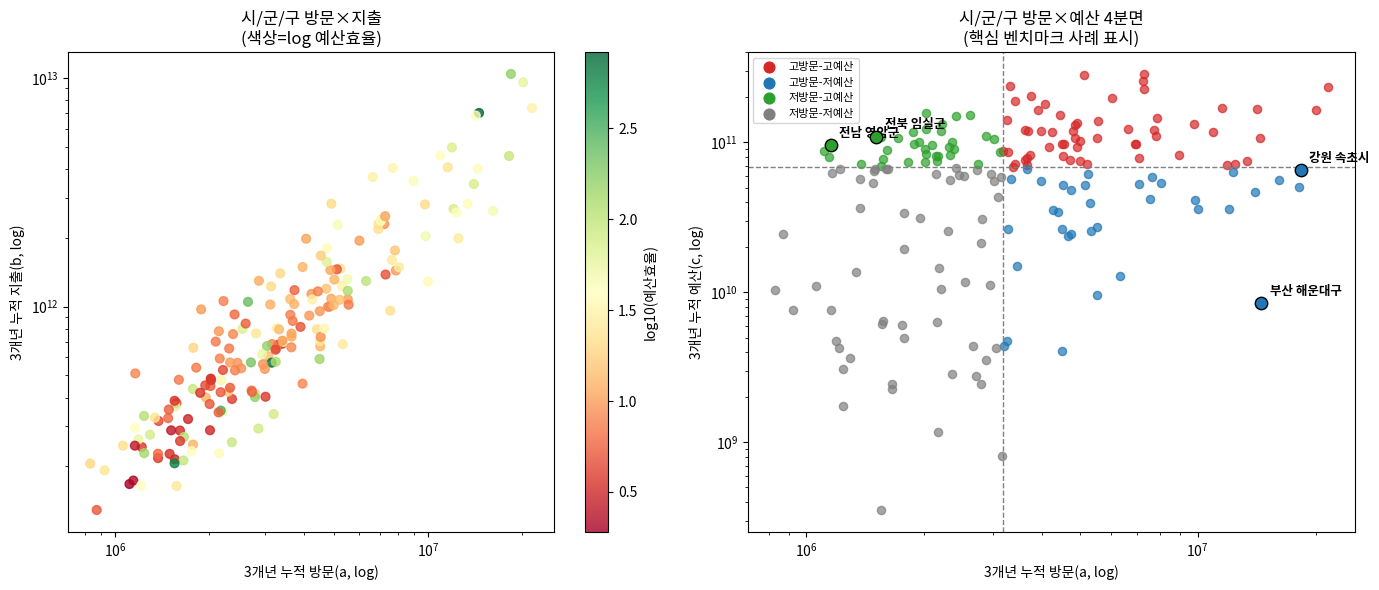

In [ ]:
# 방문×예산 4분면 산점도 (시/군/구)
v_med_sgg = reliable['visits'].median()
b_med_sgg = reliable['budget'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── 왼쪽: 방문×지출 산점도 (시군구)
ax = axes[0]
sc1 = ax.scatter(reliable['visits'], reliable['spend'],
                 c=np.log10(reliable['예산효율']), cmap='RdYlGn', s=40, alpha=0.8)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('3개년 누적 방문(a, log)'); ax.set_ylabel('3개년 누적 지출(b, log)')
ax.set_title('시/군/구 방문×지출\n(색상=log 예산효율)')
plt.colorbar(sc1, ax=ax, label='log10(예산효율)')

# ── 오른쪽: 방문×예산 산점도 + 4분면
ax = axes[1]
quad_colors_sgg = {'고방문-고예산':'#d62728','고방문-저예산':'#1f77b4',
                   '저방문-고예산':'#2ca02c','저방문-저예산':'#7f7f7f'}
for _, row in reliable.iterrows():
    q = ('고' if row['visits']>=v_med_sgg else '저')+'방문-'+('고' if row['budget']>=b_med_sgg else '저')+'예산'
    ax.scatter(row['visits'], row['budget'], color=quad_colors_sgg[q], s=35, alpha=0.7)
ax.axvline(v_med_sgg, ls='--', c='gray', lw=1)
ax.axhline(b_med_sgg, ls='--', c='gray', lw=1)
for q,c in quad_colors_sgg.items():
    ax.scatter([],[],color=c,s=60,label=q)
ax.legend(fontsize=8)

# 핵심 사례 라벨 (② 기준으로 일관되게 확인된 4개 핵심 사례만 표시)
for sido,gun,offset in [('전남','영암군',(6,6)),('전북','임실군',(6,6)),
                         ('부산','해운대구',(6,6)),('강원','속초시',(6,6))]:
    row = reliable[(reliable['dest_sido']==sido)&(reliable['dest_sigungu']==gun)]
    if len(row):
        r = row.iloc[0]
        ax.scatter(r['visits'], r['budget'], s=80, edgecolors='black', zorder=5,
                   color=quad_colors_sgg[('고' if r['visits']>=v_med_sgg else '저')+'방문-'+('고' if r['budget']>=b_med_sgg else '저')+'예산'])
        ax.annotate(f'{sido} {gun}', (r['visits'], r['budget']),
                    fontsize=9, fontweight='bold', xytext=offset, textcoords='offset points')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('3개년 누적 방문(a, log)'); ax.set_ylabel('3개년 누적 예산(c, log)')
ax.set_title('시/군/구 방문×예산 4분면\n(핵심 벤치마크 사례 표시)')

plt.tight_layout()
plt.show()

In [ ]:
# 벤치마크 후보 추출
b_hi = reliable['budget'].quantile(0.7)
v_lo = reliable['visits'].quantile(0.3)
b_lo = reliable['budget'].quantile(0.3)
v_hi = reliable['visits'].quantile(0.7)
v_hi2 = reliable['visits'].quantile(0.8)
s_lo2 = reliable['건당지출'].quantile(0.2)

mismatch  = reliable[(reliable['budget']>=b_hi)&(reliable['visits']<=v_lo)].sort_values('예산효율')
efficient = reliable[(reliable['budget']<=b_lo)&(reliable['visits']>=v_hi)].sort_values('예산효율', ascending=False)
daytrip   = reliable[(reliable['visits']>=v_hi2)&(reliable['건당지출']<=s_lo2)].sort_values('visits', ascending=False)

print('[미스매치] 예산상위30% & 방문하위30% (예산효율 낮은 순):')
print(mismatch[['dest_sido','dest_sigungu','visits','budget','방문당예산','예산효율','n_obs']].head(8).to_string(index=False))

print('\n[효율] 예산하위30% & 방문상위30% (예산효율 높은 순):')
print(efficient[['dest_sido','dest_sigungu','visits','budget','예산효율','n_obs']].head(5).to_string(index=False))

print('\n[지출전환미흡] 방문상위20% & 건당지출하위20%:')
print(daytrip[['dest_sido','dest_sigungu','visits','건당지출','예산효율','n_obs']].to_string(index=False))

[미스매치] 예산상위30% & 방문하위30% (예산효율 낮은 순):
dest_sido dest_sigungu       visits       budget     방문당예산  예산효율  n_obs
       전남          영암군 1,155,683.84  95562589550 82,689.22  2.58    178
       전북          임실군 1,509,552.94 109285393737 72,395.87  2.63    163
       전북          익산시 1,709,308.18 106839490596 62,504.52  3.02    185
       경남          고성군 2,020,170.60 156138449506 77,289.73  3.10    182
       충남          청양군 1,548,121.91 108445155145 70,049.49  3.57    185
       전남          강진군 1,868,953.10 117387039235 62,808.98  3.58    291
       경북          영주시 2,024,389.11 123865430590 61,186.57  3.85    219
       경북          상주시 1,940,006.61 100135149509 51,615.88  4.52    192

[효율] 예산하위30% & 방문상위30% (예산효율 높은 순):
dest_sido dest_sigungu        visits      budget   예산효율  n_obs
       부산         해운대구 14,537,151.54  8476306660 830.16   1430
       대전          유성구  5,536,223.22  9670290940 121.29    639
       경기          광주시  6,332,292.93 12896107880 100.41    418
       경기          용인시 12

## A-7-1. 정책 시사점 — 시/군/구 단위 3원관계 기반

> 정량 수치는 2023~2025 3개년 누적, 예산(c) = 관광(062)+문화재(064) 기준(②), 연평균 표본 30건 미만 시군구 제외.
> 단, **영동군은 예외적으로 065(문화및관광일반)를 포함한 검증된 수치를 사용한다** — 이유는 아래 A-7-2 참고.

In [ ]:
# [사례별 예외 검증] 충북 영동군 — 065 세부사업을 전수 확인한 결과 분석포함=True 100%(False 0원)로
# 확정되어, 이 지역만 예외적으로 065를 포함한 예산으로 재계산한다.
# (전체 시/군/구에 065를 다시 넣는 것이 아니라, "직접 검증이 끝난 이 지역 하나"에만 적용하는 것)
yd_065 = (df2[(df2['region']=='충북') & (df2['municipality']=='영동군') & (df2['subsector']=='문화및관광일반')]
          ['local_own_revenue'].sum())
yd_row = reliable[(reliable['dest_sido']=='충북') & (reliable['dest_sigungu']=='영동군')]
if len(yd_row):
    yd_budget_with_065 = yd_row['budget'].values[0] + yd_065
    yd_rank_with_065 = (agg_sgg['budget'] + agg_sgg.merge(
        df2[(df2['subsector']=='문화및관광일반')].groupby(['region','municipality'])['local_own_revenue'].sum().reset_index()
        .rename(columns={'region':'dest_sido','municipality':'dest_sigungu','local_own_revenue':'b065'}),
        on=['dest_sido','dest_sigungu'], how='left')['b065'].fillna(0)
    ).rank(ascending=False)
    yd_idx = agg_sgg.index[(agg_sgg['dest_sido']=='충북') & (agg_sgg['dest_sigungu']=='영동군')]
    print(f'영동군 예산(②, 065 미포함): {yd_row["budget"].values[0]/1e8:,.0f}억원')
    print(f'영동군 예산(065 포함, 검증됨): {yd_budget_with_065/1e8:,.0f}억원')
    print(f'영동군 예산효율(065 포함 기준): {yd_row["spend"].values[0]/yd_budget_with_065:.2f}배')

영동군 예산(②, 065 미포함): 643억원
영동군 예산(065 포함, 검증됨): 1,848억원
영동군 예산효율(065 포함 기준): 1.92배


**① [미스매치 최우선] 충북 영동군 — 065 세부사업 전수 검증 완료, 예산 최상위권·방문 최하위권**
- 065(문화및관광일반) 사업명을 전수 확인한 결과 **분석포함=True 100%, False 0원**으로 확정
  (초강천빙벽장 관광명소화, 레인보우힐링관광지 조성, 영동 통합관광안내센터, 영동축제관광재단 운영 등 — 전부 관광 고유 사업)
- 검증된 예산(관광+문화재+065) 약 1,848억원, 방문 하위권(신뢰표본 중 165위), 예산효율(지출/예산) 약 1.9배 —
  신뢰표본 중앙값(약 13.5배)의 1/7 수준
- 제언: 대규모 관광 조성사업 대비 방문 전환이 낮음 — 완공·홍보 시점과 방문 데이터를 대조해 "투자 대비 성과 시차"
  문제인지, 콘텐츠 자체의 흡인력 문제인지 후속 확인 필요

**② [미스매치 보조 사례] 전남 영암군 · 전북 임실군 — 065 영향이 아예 없는(0~2%) 가장 안전한 사례**
- 영암군: 예산 955억원, 방문 하위권(180위), 예산효율 2.6배
- 임실군: 예산 1,010억원, 방문 하위권(163위), 예산효율 2.6배
- 제언: 영동군과 마찬가지로 대규모 시설 조성사업의 착공·완공 시점과 방문 데이터 대조 필요

**③ [효율 벤치마크 A] 부산 해운대구 — 예산 최하위권, 방문 최상위권**
- 예산 36~85억원(정의에 따라 소폭 차이, 신뢰표본 최하위권), 방문 1,454만 건(6위), 예산효율 830배 이상
- 기존 인프라(해수욕장 등)·민간투자 중심의 자생형 구조 — "저예산·고성과"의 원인이 예산 집행 효율이 아니라 기존 인프라 효과임을 발표 시 명확히 구분. 예산 삭감 근거로 오용 금지

**④ [효율 벤치마크 B] 강원 속초시 — 방문 전국 1위, 예산 중위권**
- 방문 1,838만 건(전체 시/군/구 중 최다), 예산 657억원(중위권), 예산효율 160배 이상으로 상위권
- 해운대구(광역시 상권형)와 다른 "지방 중소도시형 자생 관광지" 벤치마크로 별도 유형 제시

**⑤ [지출전환미흡] 경기 양평군·파주시·수원시·남양주시 — 고방문·저건당지출형**
- 4개 지역 모두 방문 상위 20%·건당지출 하위 20%에 해당. 수도권 근접 당일치기형 소비 패턴으로 추정
- 제언: "예산 확대"보다 체류형 소비(숙박·야간관광) 연계 사업으로 예산 성격 전환이 방문×지출 격차를 좁히는 데 더 유효할 가능성 (원인은 방문 목적·체류시간 데이터 부재로 확정 불가 — 후속 검증 필요)

---

## A-7-2. 왜 영동군만 예외를 두는가 — 판단 기준

065(문화및관광일반)를 노트북 전체에서 일괄 포함하거나 일괄 제외하는 대신, **"전체 통계는 기계적으로 통일된
기준(②)을 쓰고, 이름을 걸고 발표하는 개별 사례는 사업명을 직접 확인한 뒤 검증된 숫자를 쓴다"**는 원칙을 적용했다.

- **전체 상관계수 계산(183개 시/군/구)**: 하나하나 사업명을 확인할 수 없는 규모이므로, 정의가 명확한 ②를
  기계적으로 통일 적용한다. 정의를 바꿔도 상관계수 결론은 편차 0.035~0.08 이내로 견고함을 A-6에서 이미 확인했다.
- **이름을 걸고 제시하는 개별 사례(5개)**: 해당 지역 하나만 사업명을 전부 읽어보는 것이 가능하므로, 확인된
  사실을 반영한다. 영동군은 065가 100% 관광 콘텐츠임이 확인되어 그 검증된 수치를 그대로 사용하고, 반대로
  달성군은 065의 65%가 무관 사업으로 확인되어 사례에서 제외한다.
- 이 기준을 적용하면 "왜 어떤 지역은 065를 넣고 어떤 지역은 뺐는가"라는 질문에 **"넣은 지역은 직접 확인해서
  전부 관광사업이었고, 뺀 지역은 확인 결과 아니었다"**고 답할 수 있다 — 임의 선택이 아니라 실사(audit) 결과다.

### 참고 — 추가 검토했으나 정량 사례로는 채택하지 않은 지역

- **경북 의성군**: 065 상위 항목(관광지개발·관광벨트화지원·관광홍보)은 관광 콘텐츠로 확인되었으나, 영동군처럼
  분석포함 여부를 전 항목 단위로 100% 확인하지는 않았다 — 참고사례로만 언급하며, 전수 검증 완료 시 정량
  사례로 승격 가능
- **대구 달성군**: 065의 약 65%(학교시설·공공청사 리뉴얼)가 관광과 무관함이 확인되어 사례에서 제외
- **제주**: 특별자치도로 기초자치단체(시/군/구)가 없어 세출 데이터가 전량 "본청"으로만 집계됨 — 구조적으로
  시/군/구 벤치마크 비교 대상에서 제외
- **종합 시사점**: "문화및관광일반(065)"은 지자체별 사업 분류 관행이 크게 달라(관광 콘텐츠부터 일반 행정까지
  혼재) 지역 간 비교의 신뢰도를 해칠 수 있다. 향후 지방재정365 세부사업 분류 시 사업명 기반 표준 가이드라인
  도입을 제언한다.

---
## PART B. 트랙2 — 챗봇 데이터셋 생성 과정

목적: df1(국민여행조사 응답자 원자료)로부터 지역×월 단위 챗봇/시각화용 요약 데이터셋을 생성하는
3단계 가공 절차(①컬럼 서브셋 → ②SPOT코드 디코딩 → ③WT_DOM 가중집계)를 그대로 수행한다.
별도의 완성본 파일과 비교·검증하는 절차는 포함하지 않으며(팀 원본 파일 2종만 사용하는 이번 노트북
범위 밖), 이 섹션의 산출물(`chatbot_dataset`)이 최종 생성 결과물이다.

In [ ]:
# ① 컬럼 서브셋 — 1회차(trip1) 데이터만 사용 (클러스터 표준오차 이슈 회피)
track2_cols = ['id','wt_dom','bsex','bage','binc1',
               'trip1_start_year','trip1_start_month','trip1_spot_cd',
               'trip1_case','trip1_cost','trip1_num','trip1_cost_per_person','year']
subset = df1[track2_cols].dropna(subset=['trip1_spot_cd','trip1_start_month']).copy()
subset = subset.merge(df1[['id','trip1_dest_sido']].rename(columns={'trip1_dest_sido':'지역'}), on='id', how='left')
subset['월'] = subset['trip1_start_month'].astype(int)
print(f'1회차 유효 응답 수: {len(subset):,}건')

1회차 유효 응답 수: 79,730건


In [ ]:
# ② ③ WT_DOM 가중집계 (지역×월, 가중 중앙값 포함) — 챗봇/시각화용 최종 데이터셋 생성
def weighted_median(values, weights):
    order = np.argsort(values)
    v, w = np.array(values)[order], np.array(weights)[order]
    return v[np.searchsorted(np.cumsum(w), w.sum()/2)]

records = []
for (region, month), g in subset.groupby(['지역','월']):
    records.append({
        '지역': region, '월': month,
        '표본수(n)': len(g),
        '방문건수_가중합': g['wt_dom'].sum(),
        '1인평균지출_가중평균': (g['wt_dom']*g['trip1_cost_per_person']).sum()/g['wt_dom'].sum(),
        '1인평균지출_중앙값': weighted_median(g['trip1_cost_per_person'].values, g['wt_dom'].values),
    })
chatbot_dataset = pd.DataFrame(records)

# 혼잡도지수 = 지역 자기 자신의 연평균 대비 비율(자기참조형 계절지수)
chatbot_dataset['혼잡도지수'] = chatbot_dataset.groupby('지역')['방문건수_가중합'].transform(lambda x: x/x.mean()*100)

print(f'생성된 데이터셋: {chatbot_dataset.shape} (17개 지역 × 12개월 = 204여야 함)')
print(f'표본수 100건 미만 지역×월 조합: {(chatbot_dataset["표본수(n)"]<100).sum()}건 / 204건 → 챗봇 화면에 저신뢰 경고 표시 필요')
print()
print('※ 유의: "1인평균지출_중앙값"은 단순 산술 중앙값이 아니라 WT_DOM 가중 중앙값을 사용해야 한다.')
print('  (단순 중앙값 사용 시 지역·월에 따라 최대 수십% 오차가 발생할 수 있음)')
chatbot_dataset.head(10)

생성된 데이터셋: (204, 7) (17개 지역 × 12개월 = 204여야 함)
표본수 100건 미만 지역×월 조합: 37건 / 204건 → 챗봇 화면에 저신뢰 경고 표시 필요

※ 유의: "1인평균지출_중앙값"은 단순 산술 중앙값이 아니라 WT_DOM 가중 중앙값을 사용해야 한다.
  (단순 중앙값 사용 시 지역·월에 따라 최대 수십% 오차가 발생할 수 있음)


   지역   월  표본수(n)      방문건수_가중합  1인평균지출_가중평균  1인평균지출_중앙값  혼잡도지수
0  강원   1     622  8,110,129.36   160,003.82  141,333.00  96.71
1  강원   2     560  6,785,949.08   157,525.43  128,000.00  80.92
2  강원   3     567  6,683,347.83   153,103.65  126,250.00  79.69
3  강원   4     560  6,428,722.71   153,219.67  128,000.00  76.66
4  강원   5     681  8,730,673.01   157,687.85  130,000.00 104.11
5  강원   6     669  8,249,391.81   159,118.10  137,500.00  98.37
6  강원   7     842 10,577,772.86   190,210.70  166,668.00 126.13
7  강원   8     904 11,494,791.38   194,420.71  166,000.00 137.06
8  강원   9     657  8,608,171.36   162,667.98  132,500.00 102.64
9  강원  10     702  8,955,557.35   170,017.56  150,000.00 106.79

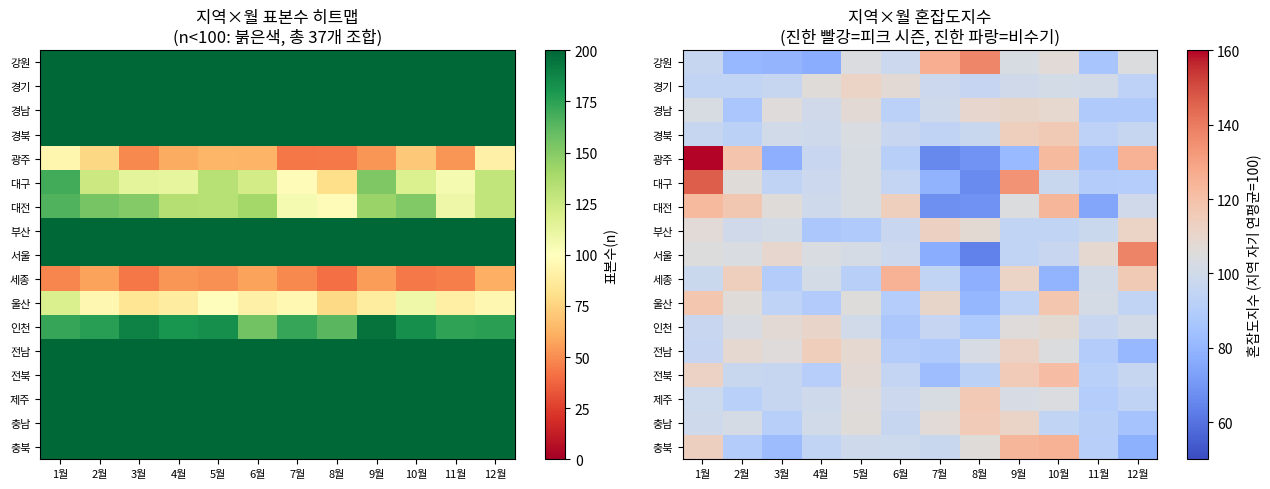

In [ ]:
# 표본수·혼잡도지수 히트맵 — 생성된 데이터셋 자체의 패턴 확인
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot = chatbot_dataset.pivot(index='지역', columns='월', values='표본수(n)')
im = axes[0].imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=200)
axes[0].set_xticks(range(12)); axes[0].set_xticklabels([f'{m}월' for m in pivot.columns], fontsize=8)
axes[0].set_yticks(range(len(pivot))); axes[0].set_yticklabels(pivot.index, fontsize=8)
plt.colorbar(im, ax=axes[0], label='표본수(n)')
axes[0].set_title(f'지역×월 표본수 히트맵\n(n<100: 붉은색, 총 {(chatbot_dataset["표본수(n)"]<100).sum()}개 조합)')

pivot2 = chatbot_dataset.pivot(index='지역', columns='월', values='혼잡도지수')
im2 = axes[1].imshow(pivot2.values, cmap='coolwarm', aspect='auto', vmin=50, vmax=160)
axes[1].set_xticks(range(12)); axes[1].set_xticklabels([f'{m}월' for m in pivot2.columns], fontsize=8)
axes[1].set_yticks(range(len(pivot2))); axes[1].set_yticklabels(pivot2.index, fontsize=8)
plt.colorbar(im2, ax=axes[1], label='혼잡도지수 (지역 자기 연평균=100)')
axes[1].set_title('지역×월 혼잡도지수\n(진한 빨강=피크 시즌, 진한 파랑=비수기)')

plt.tight_layout()
plt.show()

---
## 종합 결론

**트랙1**
1. **가설1(방문↔지출) 확인**: 시/도 Pearson r=0.675 / Spearman ρ=0.891. 3개년 모두 일관. 제주 lever 제거 시 Pearson r=0.896으로 상승 — 방문-지출 관계는 매우 견고.
2. **가설2(방문↔예산) 확인 (시/도)**: Pearson r=0.762 / Spearman ρ=0.907. 고방문 그룹이 저방문 그룹보다 평균 3.8배 많은 예산(t-test p=0.002). **단, 시/군/구로 세분화하면 Pearson r=0.313으로 급격히 약화** — 광역 단위 일률 확대보다 지역별 특성 진단이 선행돼야 함.
3. **신규 b=c(지출↔예산)**: Pearson r=0.506 / Spearman ρ=0.802. a=c보다 뚜렷하게 약함 — 예산이 방문을 이끌어도 방문객 지출 진작으로 고르게 이어지지 않는 지역이 존재.
4. **민감도 분석**: 예산 정의 3개 시나리오(관광만/+문화재/+065전체) 모두에서 a-c Pearson 0.754~0.789, 최대 편차 0.035(방법론 1-2절 기준 충족) — 결론은 예산 정의에 무관하게 견고.

**트랙2**
5. df1로부터 지역×월 단위 챗봇 데이터셋(`chatbot_dataset`)을 방법론 그대로 생성했다. "1인평균지출_중앙값"은
   반드시 WT_DOM **가중 중앙값**을 사용해야 하며, 표본수 100건 미만 조합에는 저신뢰 경고 표시가 필요하다.

**공통 한계**: 상관관계는 인과관계가 아니며 역인과 가능성을 배제할 수 없다. 방문 목적·체류일수 등 추가 변수(카드소비 데이터 등) 결합 시 원인 규명이 더 명확해질 것이다.